In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report



In [2]:
data = pd.read_csv('Telco_Customer_Churn_Dataset.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
'''Task 1 : Cleaning and Preprocessing'''

'Task 1 : Cleaning and Preprocessing'

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
data = data.drop('customerID', axis = 1)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
data['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [9]:
data['TotalCharges'] = data['TotalCharges'].replace(' ', np.nan)
data['TotalCharges'] = data['TotalCharges'].astype(float)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [10]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].mean())
data['TotalCharges'].value_counts()

TotalCharges
20.200000      11
2283.300441    11
19.750000       9
19.650000       8
19.900000       8
               ..
1990.500000     1
7362.900000     1
346.450000      1
306.600000      1
108.150000      1
Name: count, Length: 6531, dtype: int64

In [11]:
for col in data.columns:
    print(data[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No

In [12]:
data['MultipleLines'] = data['MultipleLines'].replace('No phone service', 'No')

cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols:
    data[col] = data[col].replace('No internet service', 'No')
    
for col in data.columns:
    print(data[col].value_counts())

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
StreamingMovies
No     4311
Yes    2732
Name: count, dt

In [13]:
data2 = data.copy()
data2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [14]:
data['gender'] = data['gender'].map({'Male' : 1, 'Female' : 0})

binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for feature in binary_features:
    data[feature] = data[feature].map({'Yes' : 1, 'No' : 0})
    

In [15]:
data['InternetService'] = data['InternetService'].map({'Fiber optic' : 2, 'DSL' : 1, 'No' : 0})
data['Contract'] = data['Contract'].map({'Two year' : 2, 'One year' : 1, 'Month-to-month' : 0})

In [16]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(sparse_output=False).set_output(transform= 'pandas')

oheTransform = ohe.fit_transform(data[['PaymentMethod']])


In [17]:
oheTransform

,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
7038,0.0,0.0,0.0,1.0
7039,0.0,1.0,0.0,0.0
7040,0.0,0.0,1.0,0.0
7041,0.0,0.0,0.0,1.0


In [18]:
data = pd.concat([data, oheTransform], axis = 1)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,No,1,No,Yes,...,0,1,Electronic check,29.85,29.85,0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,No,1,Yes,No,...,1,0,Mailed check,56.95,1889.50,0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,No,1,Yes,Yes,...,0,1,Mailed check,53.85,108.15,1,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,No,1,Yes,No,...,1,0,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,No,2,No,No,...,0,1,Electronic check,70.70,151.65,1,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,Yes,1,Yes,No,...,1,1,Mailed check,84.80,1990.50,0,0.0,0.0,0.0,1.0
7039,0,0,1,1,72,1,Yes,2,No,Yes,...,1,1,Credit card (automatic),103.20,7362.90,0,0.0,1.0,0.0,0.0
7040,0,0,1,1,11,0,No,1,Yes,No,...,0,1,Electronic check,29.60,346.45,0,0.0,0.0,1.0,0.0
7041,1,1,1,0,4,1,Yes,2,No,No,...,0,1,Mailed check,74.40,306.60,1,0.0,0.0,0.0,1.0


In [19]:
data = data.drop('PaymentMethod', axis=1)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,No,1,No,Yes,...,No,0,1,29.85,29.85,0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,No,1,Yes,No,...,No,1,0,56.95,1889.50,0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,No,1,Yes,Yes,...,No,0,1,53.85,108.15,1,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,No,1,Yes,No,...,No,1,0,42.30,1840.75,0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,No,2,No,No,...,No,0,1,70.70,151.65,1,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,Yes,1,Yes,No,...,Yes,1,1,84.80,1990.50,0,0.0,0.0,0.0,1.0
7039,0,0,1,1,72,1,Yes,2,No,Yes,...,Yes,1,1,103.20,7362.90,0,0.0,1.0,0.0,0.0
7040,0,0,1,1,11,0,No,1,Yes,No,...,No,0,1,29.60,346.45,0,0.0,0.0,1.0,0.0
7041,1,1,1,0,4,1,Yes,2,No,No,...,No,0,1,74.40,306.60,1,0.0,0.0,0.0,1.0


In [20]:
'''Task 2 & 6 : EDA & Visualizations'''

'Task 2 & 6 : EDA & Visualizations'

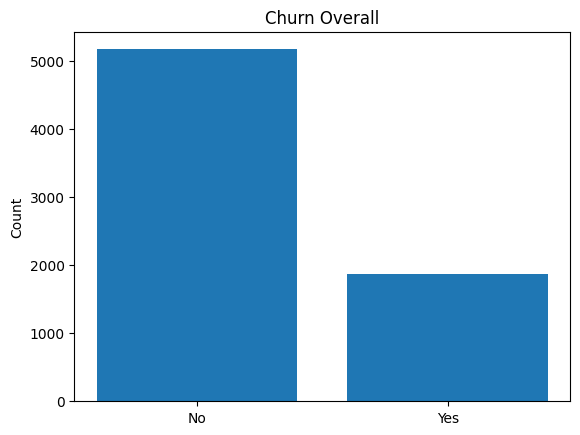

In [21]:
churn_counts = data['Churn'].value_counts()

plt.bar(churn_counts.index, churn_counts.values)
plt.title('Churn Overall')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

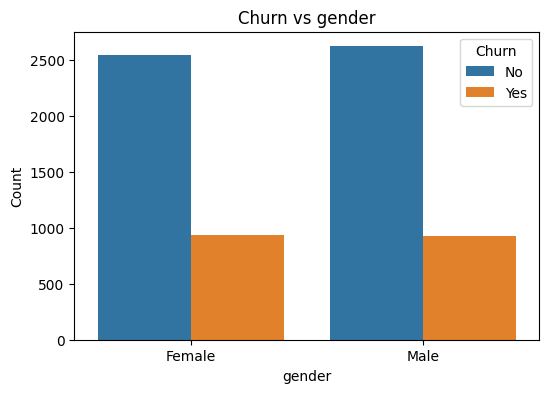

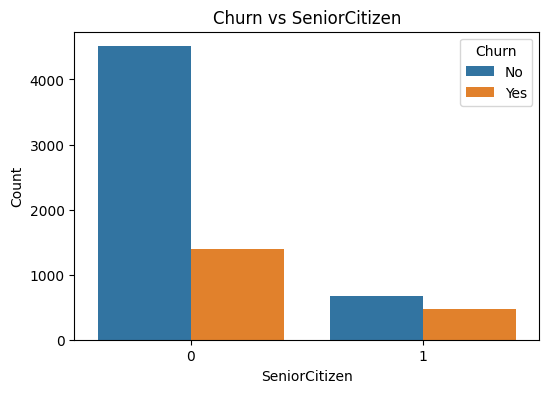

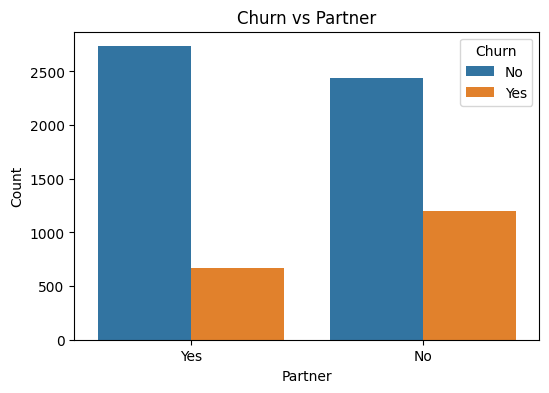

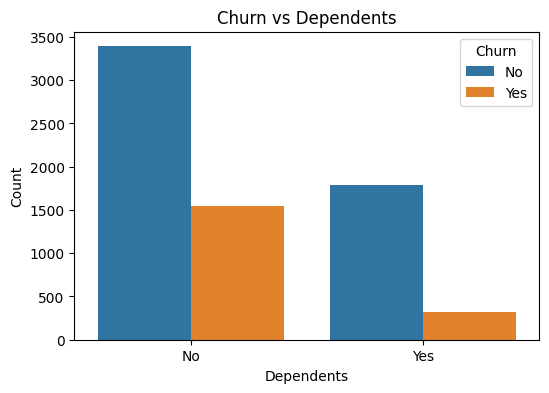

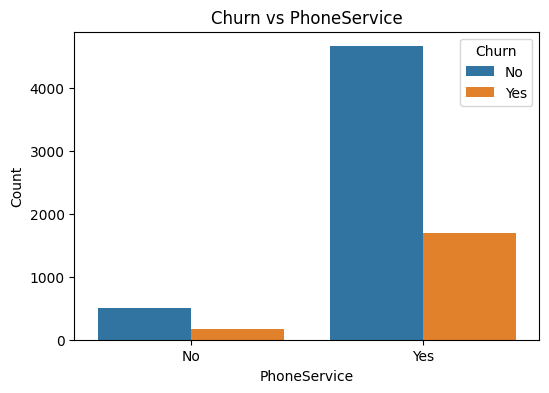

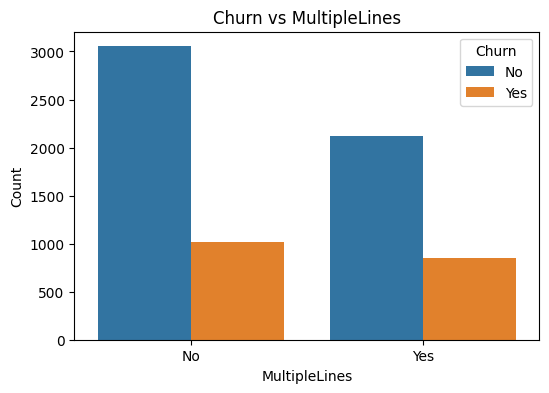

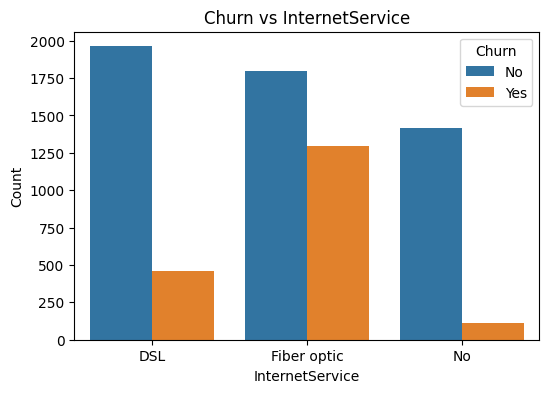

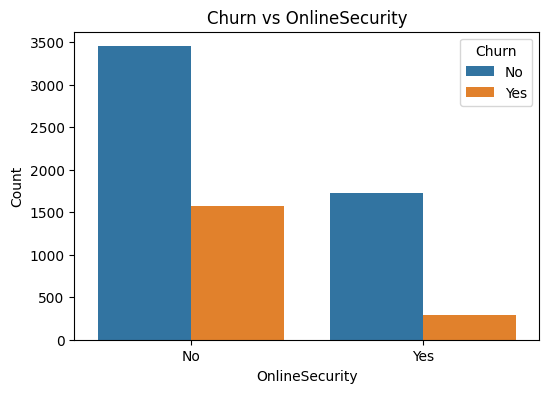

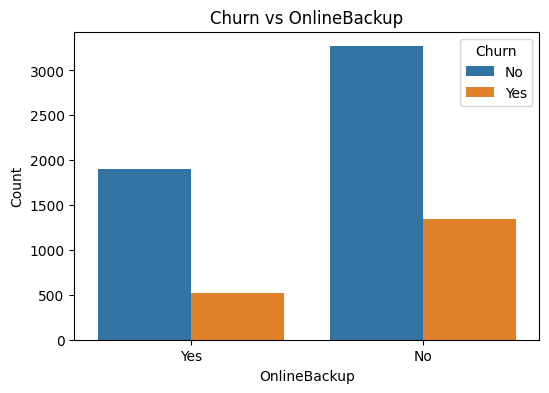

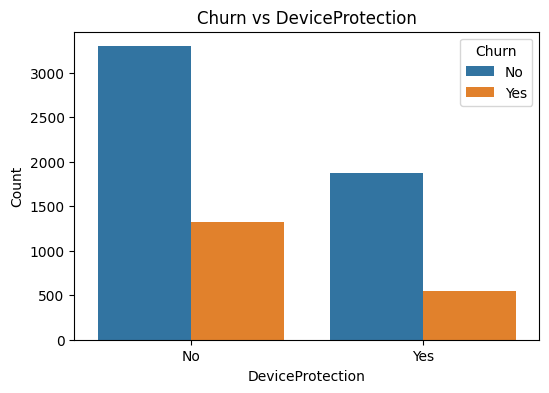

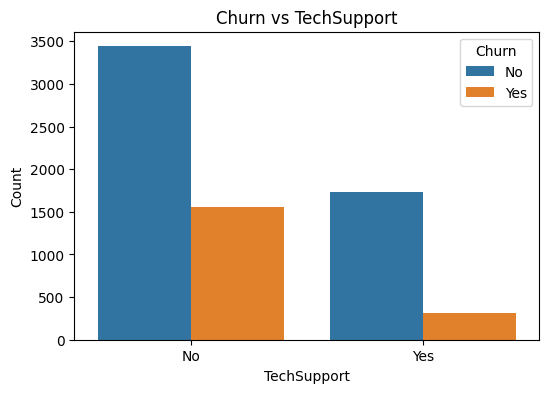

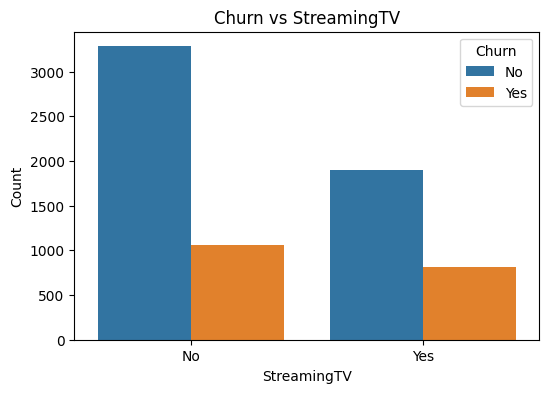

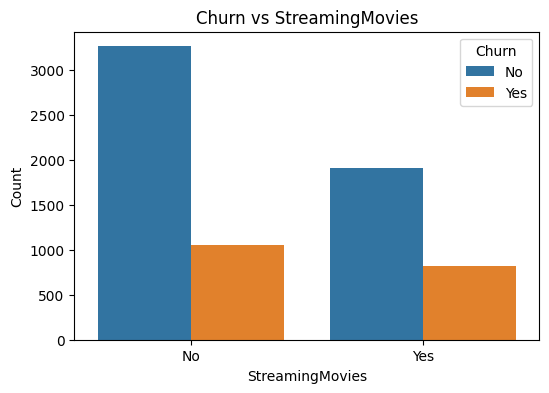

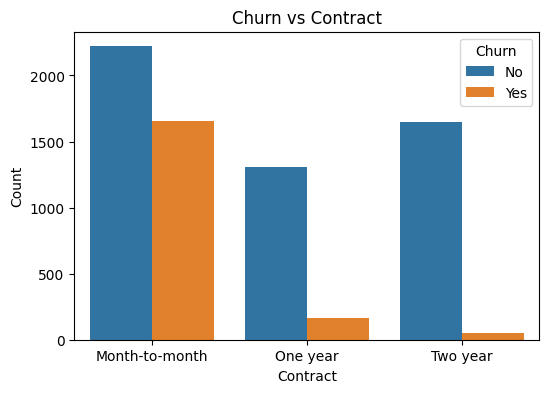

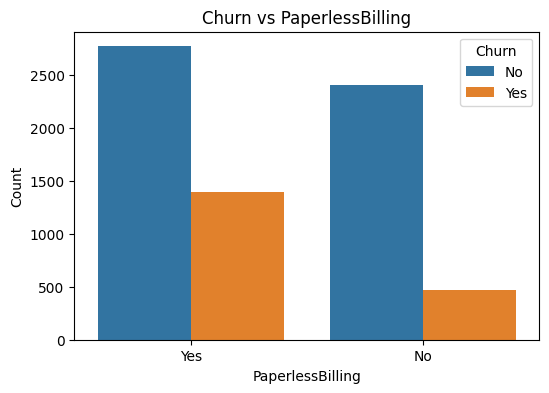

In [22]:
categorical_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
]

for cat_feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data2, x=cat_feature, hue='Churn')
    plt.title(f'Churn vs {cat_feature}')
    plt.ylabel('Count')
    plt.xlabel(cat_feature)
    plt.show()

In [23]:
'''
Gender does not affect Churn Rate

Customers who do not have PhoneService tend less to churn even more than customers that have PhoneService

Senior Customers tend to churn less than young cusotmers

Customers with no dependents or no partners tend to churn more than customers with dependents or partners

Customers with no TechSupport tend to churn more

Customers seem to prefer month-to-month contract but their churn rate is higher than other categories


'''

'\nGender does not affect Churn Rate\n\nCustomers who do not have PhoneService tend less to churn even more than customers that have PhoneService\n\nSenior Customers tend to churn less than young cusotmers\n\nCustomers with no dependents or no partners tend to churn more than customers with dependents or partners\n\nCustomers with no TechSupport tend to churn more\n\nCustomers seem to prefer month-to-month contract but their churn rate is higher than other categories\n\n\n'

In [24]:
'''

Checking Skewness of data

'''

'\n\nChecking Skewness of data\n\n'

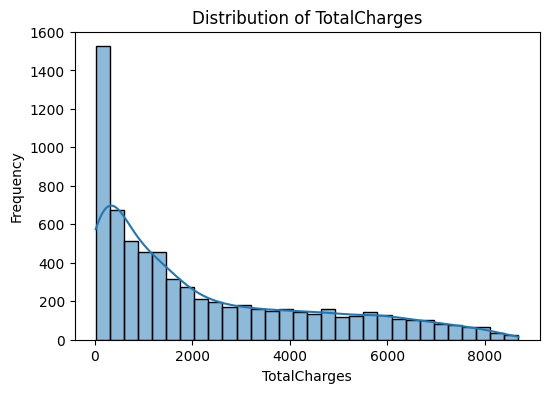

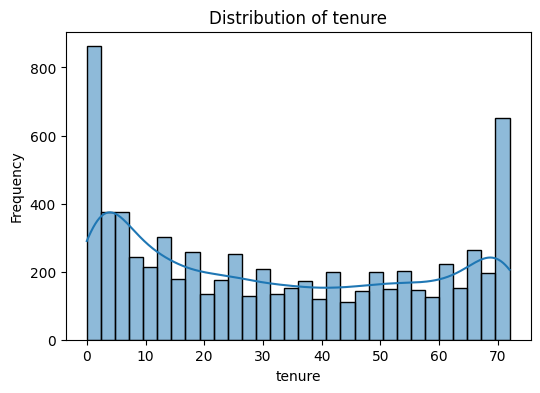

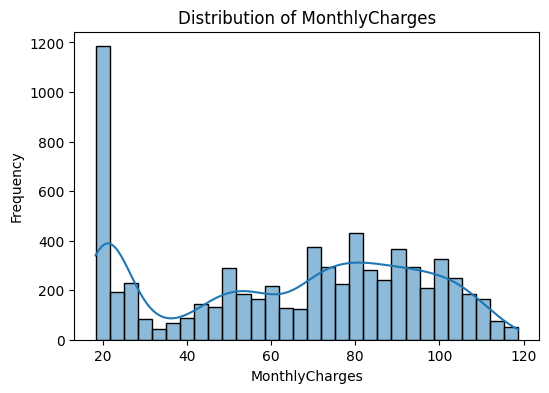

In [25]:
num_features = ['TotalCharges', 'tenure', 'MonthlyCharges']



for num_feature in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=num_feature, kde=True, bins=30)
    plt.title(f'Distribution of {num_feature}')
    plt.xlabel(num_feature)
    plt.ylabel('Frequency')
    plt.show()

In [26]:
'''
TotalCharges appears to be heavily right skewed which will make us need to transform it to resolve its skewness

'''

'\nTotalCharges appears to be heavily right skewed which will make us need to transform it to resolve its skewness\n\n'

In [27]:
data['TotalCharges'] = np.log1p(data['TotalCharges'])

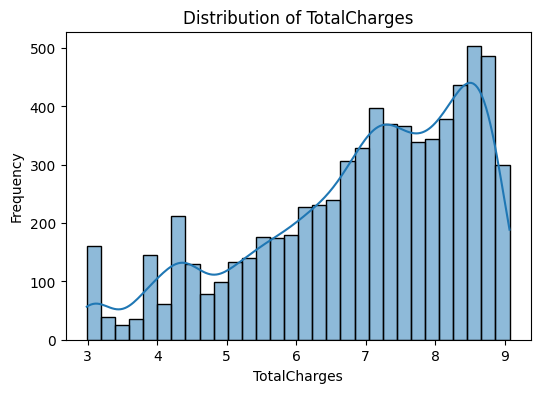

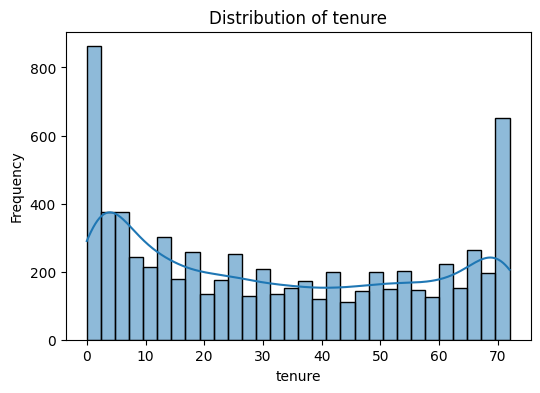

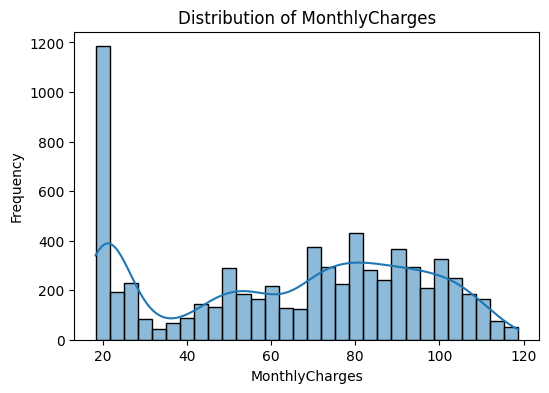

In [28]:
num_features = ['TotalCharges', 'tenure', 'MonthlyCharges']

for num_feature in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=data, x=num_feature, kde=True, bins=30)
    plt.title(f'Distribution of {num_feature}')
    plt.xlabel(num_feature)
    plt.ylabel('Frequency')
    plt.show()

In [29]:
'''

Task 4 : Churn Prediction Model (Logistic Regression)

'''

'\n\nTask 4 : Churn Prediction Model (Logistic Regression)\n\n'

In [30]:
X = data.drop('Churn', axis=1)
Y = data['Churn']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

In [32]:
X_train_scaled.T

,2142,1623,6074,1362,6754,1212,2722,4006,6791,5466,...,5334,466,6265,5734,3092,3772,5191,5226,5390,860
gender,0,0,1,1,1,1,1,1,1,1,...,0,1,0,1,0,1,0,1,1,1
SeniorCitizen,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
Partner,0,0,1,0,0,0,1,1,0,0,...,1,1,0,1,0,1,1,1,0,0
Dependents,1,0,0,0,1,0,1,1,0,1,...,1,0,0,1,0,0,1,1,0,0
tenure,-0.465683,0.885537,-1.284605,-1.161766,-1.325551,-1.038928,-0.015277,1.622566,-0.547575,-0.91609,...,0.680806,1.294997,-1.243659,1.622566,-1.284605,-1.284605,-0.383791,-0.834198,-0.834198,-0.260953
PhoneService,1,1,0,1,1,1,1,1,0,1,...,1,1,1,1,0,1,1,1,1,1
MultipleLines,No,Yes,No,No,Yes,No,No,No,No,No,...,Yes,Yes,No,Yes,No,No,Yes,No,Yes,No
InternetService,1,2,1,2,1,2,0,0,1,0,...,2,2,1,1,1,2,1,0,2,0
OnlineSecurity,Yes,No,No,No,Yes,No,No,No,No,No,...,No,No,No,Yes,No,Yes,Yes,No,No,No
OnlineBackup,No,Yes,No,No,Yes,No,No,No,No,No,...,Yes,No,No,Yes,No,No,Yes,No,No,No


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=1)

model.fit(X_train_scaled, y_train)

ValueError: could not convert string to float: 'No'

In [ ]:
model.coef_

array([[-0.05263652,  0.17104373,  0.08798985, -0.12837675, -0.05470674,
        -0.80442186,  0.29585796,  0.64453673, -0.41358435, -0.2065775 ,
        -0.0313291 , -0.33339341,  0.14705736,  0.24921053, -0.7941074 ,
         0.34541337,  0.62968114, -0.89464527, -0.29050609, -0.36662731,
        -0.02432641, -0.40247378]])

In [ ]:
'''

Different thresholds leads to different results which made us try to use 3 different thresholds to be able to identify which one is better and from the results we will find that:

Threshold = 0.1

Recall = 0.97 → almost all churners are caught

Precision = 0.41 → many false alarms

Accuracy = 0.61 → overall performance weak

Best if missing churners is very costly

/////////////////////////////////////////////////////

Threshold = 0.5

Recall = 0.60 → miss 40% of churners

Precision = 0.68 → fewer false alarms

Accuracy = 0.82 → highest overall accuracy
 
Good balance, but recall too low for churn detection

/////////////////////////////////////////////////////

Threshold = 0.3

Recall = 0.80 → catch most churners

Precision = 0.56 → moderate false alarms

Accuracy = 0.78 → still strong

F1 = 0.66 → best trade-off

Best middle ground

/////////////////////////////////////////////////////

Conclusion

If you want to catch as many churners as possible → use 0.3

If you want to save resources and reduce false alarms → use 0.5

If churn prevention is critical and false alarms don't matter → use 0.1
'''


--- Results for threshold 0.1 ---
Accuracy: 0.6288147622427254


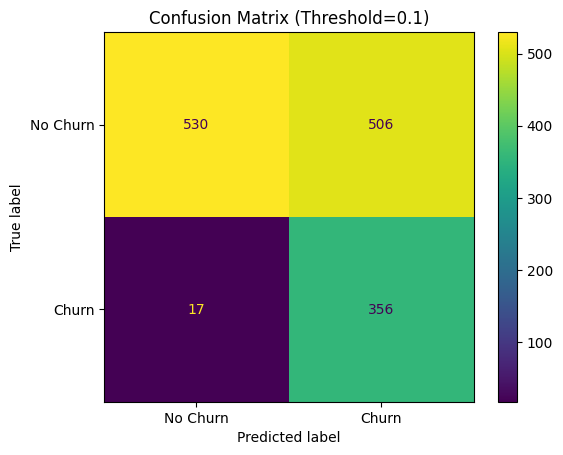

              precision    recall  f1-score   support

           0       0.97      0.51      0.67      1036
           1       0.41      0.95      0.58       373

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.63      0.64      1409


--- Results for threshold 0.3 ---
Accuracy: 0.7743080198722498


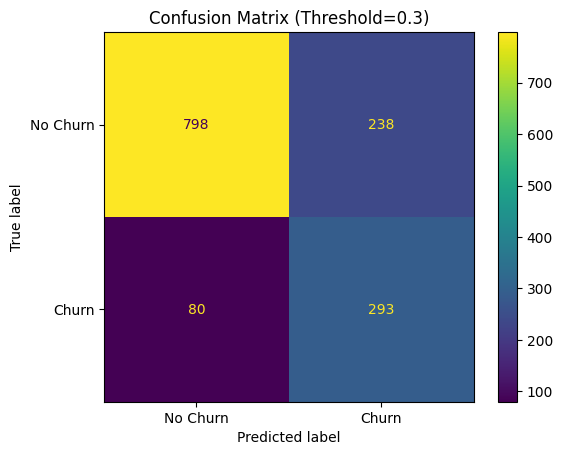

              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1036
           1       0.55      0.79      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409


--- Results for threshold 0.5 ---
Accuracy: 0.8112136266855926


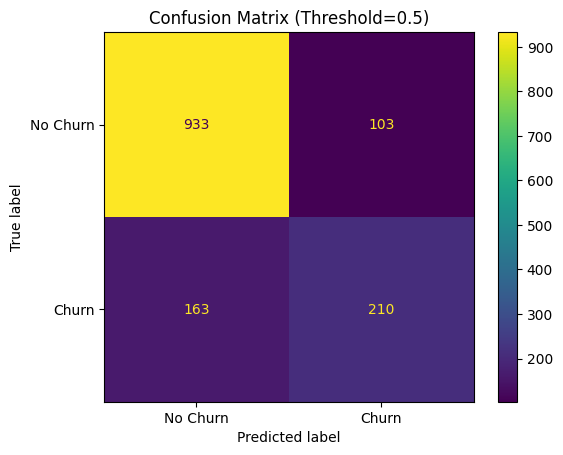

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [ ]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.1, 0.3, 0.5]

for t in thresholds:
    print(f"\n--- Results for threshold {t} ---")
    y_pred = (y_probs > t).astype(int)
    
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    
    
    co_matrix = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=co_matrix, display_labels=['No Churn', 'Churn'])
    cm_display.plot()
    plt.title(f"Confusion Matrix (Threshold={t})")
    plt.show()
    
    
    print(classification_report(y_test, y_pred))